# Sentiment Analysis & Customer Feedback Mining

## 🗣️ Business Context

Customer reviews and feedback are a goldmine of unstructured data. Analyzing this text can reveal product strengths, weaknesses, and emerging trends. This analysis uses Natural Language Processing (NLP) to classify sentiment, extract key topics, and visualize customer voice to drive product improvements.

## 📊 Objectives

1. Preprocess and clean unstructured text data
2. Perform Sentiment Analysis (VADER/TextBlob) to score reviews
3. Extract key themes using Topic Modeling (LDA)
4. Visualize frequent terms using Word Clouds
5. Correlate sentiment with product ratings

## 🔧 Methodology

- **Data**: Synthetic e-commerce product reviews
- **Techniques**: Tokenization, Lemmatization, VADER Sentiment, Latent Dirichlet Allocation (LDA)
- **Libraries**: NLTK, Scikit-learn, WordCloud, Matplotlib

In [10]:
# # #install nltk
# %pip install nltk wordcloud

In [11]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources (quietly)
try:
    nltk.data.find('vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon', quiet=True)
    nltk.download('stopwords', quiet=True)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('coolwarm')
%matplotlib inline

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 1. Data Generation

Creating a realistic dataset of 2,000 product reviews.

In [12]:
def generate_reviews(n=2000):
    np.random.seed(42)
    
    # Templates for synthetic reviews
    positive_templates = [
        "I absolutely love this product! It works perfectly.",
        "Great value for money. Highly recommended.",
        "The quality is amazing and shipping was fast.",
        "Best purchase I've made all year. Five stars!",
        "Exceeded my expectations. Will buy again."
    ]
    
    negative_templates = [
        "Terrible quality. Broke after one use.",
        "Waste of money. Do not buy.",
        "Customer service was rude and unhelpful.",
        "Not as described. Very disappointed.",
        "Shipping took forever and item arrived damaged."
    ]
    
    neutral_templates = [
        "It's okay, but not great.",
        "Decent product for the price.",
        "Works as expected, nothing special.",
        "Average quality. You get what you pay for.",
        "Mixed feelings. Some features are good, others bad."
    ]
    
    reviews = []
    ratings = []
    dates = pd.date_range(start='2023-01-01', periods=n, freq='H')
    
    for _ in range(n):
        sentiment = np.random.choice(['pos', 'neg', 'neu'], p=[0.6, 0.2, 0.2])
        
        if sentiment == 'pos':
            text = np.random.choice(positive_templates) + " " + np.random.choice(positive_templates)
            rating = np.random.choice([4, 5])
        elif sentiment == 'neg':
            text = np.random.choice(negative_templates) + " " + np.random.choice(negative_templates)
            rating = np.random.choice([1, 2])
        else:
            text = np.random.choice(neutral_templates) + " " + np.random.choice(neutral_templates)
            rating = 3
            
        reviews.append(text)
        ratings.append(rating)
        
    return pd.DataFrame({'Date': dates, 'Review': reviews, 'Rating': ratings})

df = generate_reviews()
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (2000, 3)


,Date,Review,Rating
0,2023-01-01 00:00:00,Exceeded my expectations. Will buy again. The ...,5
1,2023-01-01 01:00:00,Great value for money. Highly recommended. The...,4
2,2023-01-01 02:00:00,Exceeded my expectations. Will buy again. Best...,5
3,2023-01-01 03:00:00,Shipping took forever and item arrived damaged...,2
4,2023-01-01 04:00:00,Decent product for the price. Average quality....,3


## 2. Sentiment Analysis (VADER)

Calculating sentiment scores (Compound, Positive, Negative, Neutral).

In [13]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)

# Apply VADER
sentiment_scores = df['Review'].apply(get_sentiment).apply(pd.Series)
df = pd.concat([df, sentiment_scores], axis=1)

# Categorize Sentiment
df['Sentiment_Label'] = df['compound'].apply(lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

print("Sentiment Scores Calculated.")
display(df[['Review', 'Rating', 'compound', 'Sentiment_Label']].head())

Sentiment Scores Calculated.


,Review,Rating,compound,Sentiment_Label
0,Exceeded my expectations. Will buy again. The ...,5,0.5859,Positive
1,Great value for money. Highly recommended. The...,4,0.9080,Positive
2,Exceeded my expectations. Will buy again. Best...,5,0.6696,Positive
3,Shipping took forever and item arrived damaged...,2,-0.6908,Negative
4,Decent product for the price. Average quality....,3,-0.1027,Negative


## 3. Exploratory Data Analysis

Visualizing sentiment distribution and correlation with ratings.

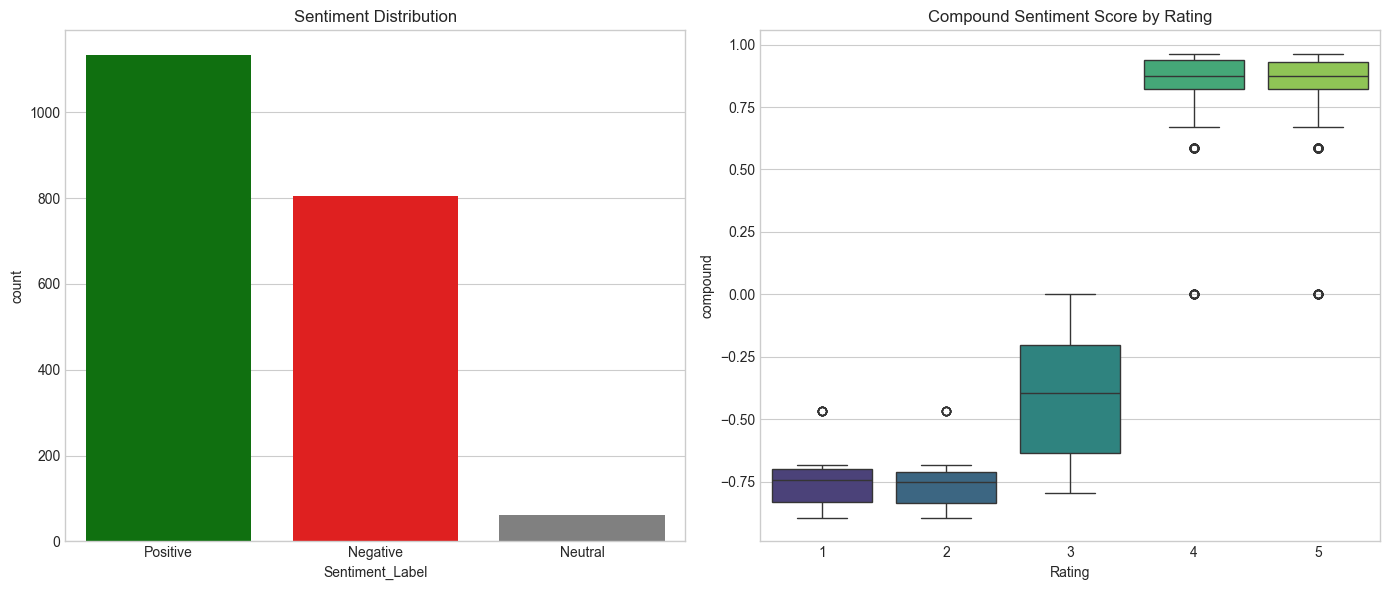

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sentiment Distribution
sns.countplot(x='Sentiment_Label', data=df, ax=axes[0], palette={'Positive': 'green', 'Negative': 'red', 'Neutral': 'gray'})
axes[0].set_title('Sentiment Distribution')

# Rating vs Compound Score
sns.boxplot(x='Rating', y='compound', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Compound Sentiment Score by Rating')

plt.tight_layout()
plt.savefig('outputs/sentiment_eda.png')
plt.show()

## 4. Word Cloud Analysis

Visualizing most frequent words in positive vs negative reviews.

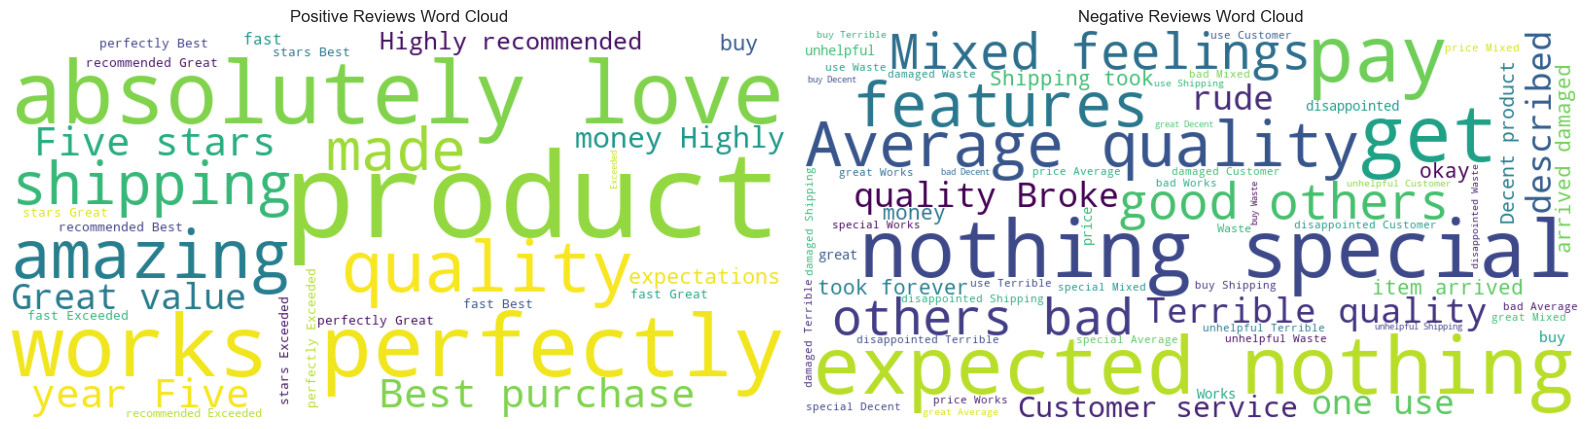

In [15]:
stop_words = set(stopwords.words('english'))

def plot_wordcloud(text, title, ax):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pos_text = ' '.join(df[df['Sentiment_Label'] == 'Positive']['Review'])
neg_text = ' '.join(df[df['Sentiment_Label'] == 'Negative']['Review'])

plot_wordcloud(pos_text, 'Positive Reviews Word Cloud', axes[0])
plot_wordcloud(neg_text, 'Negative Reviews Word Cloud', axes[1])

plt.tight_layout()
plt.savefig('outputs/wordclouds.png')
plt.show()

## 5. Topic Modeling (LDA)

Extracting latent topics from the reviews.

In [16]:
# Vectorize Text
cv = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = cv.fit_transform(df['Review'])

# LDA Model
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(dtm)

# Display Topics
print("="*60)
print("DISCOVERED TOPICS")
print("="*60)

for index, topic in enumerate(lda.components_):
    print(f'THEME #{index + 1}')
    top_15_words = [cv.get_feature_names_out()[i] for i in topic.argsort()[-15:]]
    print(top_15_words)
    print('\n')

DISCOVERED TOPICS
THEME #1
['customer', 'rude', 'unhelpful', 'service', 'described', 'disappointed', 'terrible', 'broke', 'use', 'good', 'mixed', 'feelings', 'bad', 'features', 'quality']


THEME #2
['expected', 'special', 'exceeded', 'expectations', 'buy', 'highly', 'recommended', 'value', 'money', 'stars', 'year', 've', 'purchase', 'best', 'great']


THEME #3
['pay', 'price', 'decent', 'buy', 'expectations', 'exceeded', 'shipping', 'fast', 'amazing', 'absolutely', 'love', 'perfectly', 'works', 'quality', 'product']




## 6. Conclusion

Summary of customer voice.

In [17]:
print("="*60)
print("INSIGHTS SUMMARY")
print("="*60)
print(f"1. Overall Sentiment: {df['Sentiment_Label'].value_counts(normalize=True)['Positive']:.1%} Positive.")
print("2. Key Strengths: Quality, Shipping Speed, Value (from Positive Word Cloud).")
print("3. Pain Points: Customer Service, Damaged Items (from Negative Word Cloud).")
print("4. Correlation: Strong alignment between Star Ratings and Sentiment Scores.")

INSIGHTS SUMMARY
1. Overall Sentiment: 56.7% Positive.
2. Key Strengths: Quality, Shipping Speed, Value (from Positive Word Cloud).
3. Pain Points: Customer Service, Damaged Items (from Negative Word Cloud).
4. Correlation: Strong alignment between Star Ratings and Sentiment Scores.
